
# Pemilihan Platform Digital Terbaik untuk UMKM

Di era digital, UMKM harus memilih platform digital yang paling sesuai untuk memasarkan produk mereka. Dengan menggunakan AI, bisnis dapat menganalisis kinerja berbagai platform digital berdasarkan konversi penjualan, interaksi pengguna, dan biaya pemasaran. AI membantu UMKM dalam memilih platform yang memberikan hasil terbaik dengan anggaran yang tersedia, meningkatkan efisiensi pemasaran digital mereka. Pemilik UMKM, tim pemasaran, dan analis digital dapat memanfaatkan teknologi ini untuk membuat keputusan yang lebih baik dalam memilih platform yang sesuai dengan target pasar mereka. Model AI dapat memberikan wawasan berbasis data yang membantu bisnis memaksimalkan pengaruh pemasaran mereka di dunia digital.



## Langkah 1: Memuat Dataset

Kita akan menggunakan data dummy yang berisi informasi tentang platform digital, jumlah kunjungan, tingkat konversi, biaya iklan, dan total penjualan. Data ini akan membantu kita menganalisis platform mana yang memiliki performa terbaik.


In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel('23_platform_digital_umkm.xlsx')
df

,Platform,Kunjungan,Konversi,Biaya_Iklan,Penjualan
0,Google Ads,12156,0.05,4065144,142718125
1,Shopee,23597,0.04,2749144,221633406
2,Facebook,10149,0.07,2084227,166816778
3,Facebook,16863,0.05,3166128,197980894
4,Instagram,16674,0.07,3343896,274066702
...,...,...,...,...,...
295,Shopee,16762,0.07,3756594,275513138
296,Facebook,16094,0.07,3544674,264533376
297,Shopee,23251,0.07,4667678,382171339
298,Google Ads,18522,0.04,4639800,173966773



## Langkah 2: Visualisasi Data

Visualisasi membantu memahami pola data. Kita akan membuat grafik untuk membandingkan performa antar platform.


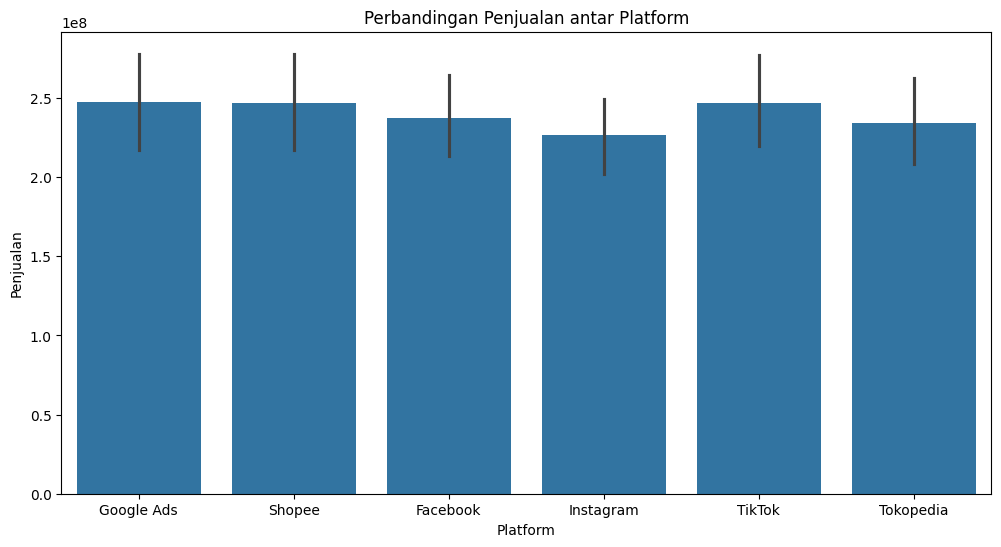

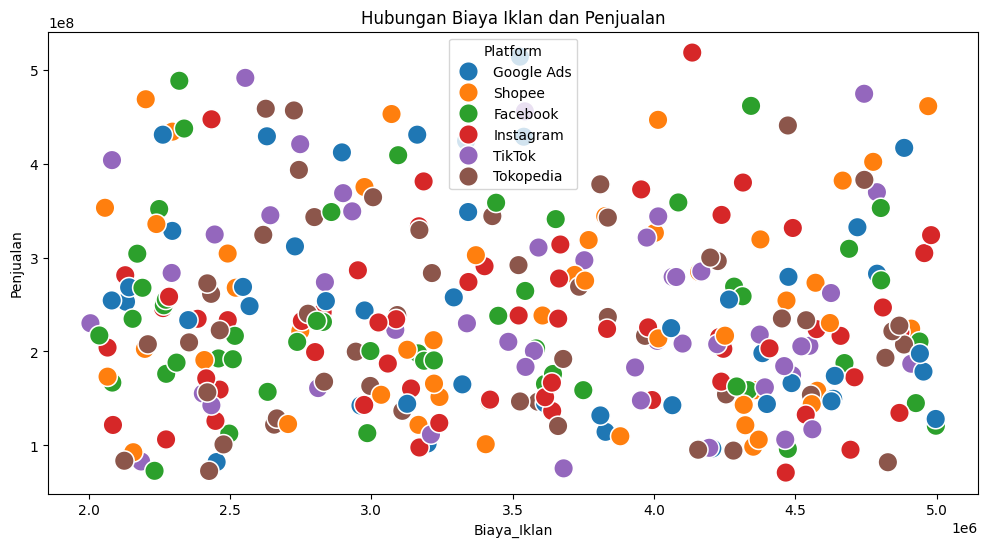

In [2]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Platform', y='Penjualan', data=df)
plt.title('Perbandingan Penjualan antar Platform')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Biaya_Iklan', y='Penjualan', hue='Platform', data=df, s=200)
plt.title('Hubungan Biaya Iklan dan Penjualan')
plt.show()



## Langkah 3: Preprocessing Data

Tahap ini meliputi pembersihan data dan transformasi variabel agar siap digunakan dalam model machine learning.


In [3]:

from sklearn.preprocessing import MinMaxScaler

# Memilih fitur yang relevan
features = df[['Kunjungan', 'Konversi', 'Biaya_Iklan', 'Penjualan']]

# Normalisasi data
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# Membuat DataFrame baru
df_scaled = pd.DataFrame(scaled_features, columns=['Kunjungan', 'Konversi', 'Biaya_Iklan', 'Penjualan'])
df_scaled['Platform'] = df['Platform'].values
print("Data setelah normalisasi:")
print(df_scaled)


Data setelah normalisasi:
     Kunjungan  Konversi  Biaya_Iklan  Penjualan    Platform
0     0.143297  0.333333     0.688288   0.160469  Google Ads
1     0.908683  0.166667     0.248232   0.336694      Shopee
2     0.009031  0.666667     0.025891   0.214283    Facebook
3     0.458188  0.333333     0.387667   0.283876    Facebook
4     0.445545  0.666667     0.447111   0.453783   Instagram
..         ...       ...          ...        ...         ...
295   0.451432  0.666667     0.585112   0.457013      Shopee
296   0.406743  0.666667     0.514248   0.432494    Facebook
297   0.885537  0.666667     0.889769   0.695192      Shopee
298   0.569173  0.166667     0.880447   0.230250  Google Ads
299   0.643431  0.166667     0.820583   0.253532      TikTok

[300 rows x 5 columns]



## Langkah 4: Membagi Data Train dan Test

Data akan dibagi menjadi data latih dan uji untuk melatih dan menguji model.


In [4]:

from sklearn.model_selection import train_test_split

X = df_scaled[['Kunjungan', 'Konversi', 'Biaya_Iklan']]
y = df_scaled['Penjualan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data latih:")
print(X_train)
print("Data uji:")
print(X_test)


Data latih:
     Kunjungan  Konversi  Biaya_Iklan
194   0.922799  0.333333     0.688665
101   0.227321  0.666667     0.957917
68    0.422531  0.333333     0.168431
224   0.762309  0.833333     0.925844
37    0.476519  0.166667     0.269324
..         ...       ...          ...
188   0.912898  0.333333     0.554303
71    0.045826  0.000000     0.559690
106   0.040005  0.500000     0.878568
270   0.679957  0.666667     0.830789
102   0.243243  0.000000     0.824915

[210 rows x 3 columns]
Data uji:
     Kunjungan  Konversi  Biaya_Iklan
203   0.287263  0.666667     0.817856
266   0.014785  0.500000     0.374643
152   0.774886  0.166667     0.748600
9     0.008295  0.166667     0.899007
233   0.513647  0.333333     0.067917
..         ...       ...          ...
114   0.059607  0.333333     0.999785
118   0.198889  0.166667     0.217276
72    0.697485  0.000000     0.800114
15    0.647110  0.833333     0.930249
10    0.325662  0.500000     0.116679

[90 rows x 3 columns]



## Langkah 5: Melatih Model

Kita akan menggunakan model regresi linear sederhana untuk memprediksi penjualan berdasarkan faktor-faktor utama.


In [5]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Koefisien Model:", model.coef_)
print("Intercept Model:", model.intercept_)


Koefisien Model: [0.44816088 0.56678523 0.00136386]
Intercept Model: -0.11553309191765754



## Langkah 6: Evaluasi Model

Evaluasi model dilakukan dengan menghitung R^2 score, yang mengukur seberapa baik model memprediksi data uji.


In [6]:

from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2)


R^2 Score: 0.9597940528507145



## Langkah 7: Prediksi

Terakhir, kita akan mencoba memprediksi penjualan dari data platform baru.


In [10]:
# Contoh prediksi untuk platform baru
new_data = pd.DataFrame([[17000, 0.06, 3500000]], columns=['Kunjungan', 'Konversi', 'Biaya_Iklan'])
# Create a temporary DataFrame with all features, including 'Penjualan'
# Initialize 'Penjualan' with a dummy value, it won't affect the scaling of other features
new_data_with_penjualan = new_data.copy()
new_data_with_penjualan['Penjualan'] = 0
# Select only the columns used during the fitting of the scaler
scaled_new_data = scaler.transform(new_data_with_penjualan[['Kunjungan', 'Konversi', 'Biaya_Iklan', 'Penjualan']])
# Remove the 'Penjualan' column from the scaled data before prediction
scaled_new_data = scaled_new_data[:, :-1]
predicted_sales = model.predict(scaled_new_data)
print("Prediksi Penjualan:", predicted_sales[0])

Prediksi Penjualan: 0.3779900598575596


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
